In [160]:
import numpy as np
## Write your code here
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sympy.physics.units import length
from torch.utils.data import DataLoader, TensorDataset
import torch
torch.manual_seed(0)
#Load the dataset
data = pd.read_csv("league_of_legends_data_large.csv")

print(data.shape)
print(data.columns)
print(data.dtypes)

#Split data into features and target
X = data.drop('win', axis=1)
y = data['win']

column_name = X.columns

print(y.value_counts())

#Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Convert it into tensor
X_train = torch.tensor(X_train, dtype=torch.float)
y_train = torch.tensor(y_train.values, dtype= torch.float)
X_test = torch.tensor(X_test, dtype=torch.float)
y_test = torch.tensor(y_test.values, dtype= torch.float)


(1000, 9)
Index(['win', 'kills', 'deaths', 'assists', 'gold_earned', 'cs',
       'wards_placed', 'wards_killed', 'damage_dealt'],
      dtype='object')
win             int64
kills           int64
deaths          int64
assists         int64
gold_earned     int64
cs              int64
wards_placed    int64
wards_killed    int64
damage_dealt    int64
dtype: object
win
1    510
0    490
Name: count, dtype: int64


In [161]:
## Write your code here
from torch import nn

#Create a class LogisticRegressionModel 
class LogisticRegressionModel(nn.Module):
    def __init__(self, input):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input, 1)

    def forward(self, x):
        x = self.linear(x)
        return torch.sigmoid(x)


#Initialize the Model
model = LogisticRegressionModel(X.shape[1])

# Loss Function
criterion = nn.BCELoss()

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [162]:
epochs = 1000
train_loss = []
test_loss = []
predictions_test_result = []
predictions_train_result = []
for epoch in range(epochs):
    model.train()
    yhat = model(X_train).view(-1)
    loss = criterion(yhat, y_train)
    predictions = (yhat > 0.5).float()
    predictions_train_result = predictions.numpy()
    train_correct = (predictions == y_train).sum().item()
    train_loss.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        yhat = model(X_test).view(-1)
        loss = criterion(yhat, y_test)
        predictions = (yhat > 0.5).float()
        predictions_test_result = predictions.numpy()
        test_correct = (predictions == y_test).sum().item()
        test_loss.append(loss.item())
    
    p_train = (train_correct / X_train.shape[0]) * 100
    p_test = (test_correct / X_test.shape[0]) * 100
    
    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Loss = {train_loss[epoch]:.4f}, Accuracy = {p_train:.2f}%")
        print(f"Epoch {epoch}: Test Loss = {test_loss[epoch]:.4f}, Accuracy = {p_test:.2f}%")


Epoch 0: Train Loss = 0.7356, Accuracy = 47.88%
Epoch 0: Test Loss = 0.7581, Accuracy = 49.50%
Epoch 2: Train Loss = 0.7352, Accuracy = 47.88%
Epoch 2: Test Loss = 0.7575, Accuracy = 49.50%
Epoch 4: Train Loss = 0.7348, Accuracy = 47.75%
Epoch 4: Test Loss = 0.7569, Accuracy = 49.50%
Epoch 6: Train Loss = 0.7344, Accuracy = 47.75%
Epoch 6: Test Loss = 0.7563, Accuracy = 49.50%
Epoch 8: Train Loss = 0.7340, Accuracy = 47.75%
Epoch 8: Test Loss = 0.7558, Accuracy = 49.50%
Epoch 10: Train Loss = 0.7336, Accuracy = 47.75%
Epoch 10: Test Loss = 0.7552, Accuracy = 49.50%
Epoch 12: Train Loss = 0.7332, Accuracy = 47.75%
Epoch 12: Test Loss = 0.7547, Accuracy = 49.50%
Epoch 14: Train Loss = 0.7329, Accuracy = 47.62%
Epoch 14: Test Loss = 0.7541, Accuracy = 49.50%
Epoch 16: Train Loss = 0.7325, Accuracy = 47.62%
Epoch 16: Test Loss = 0.7536, Accuracy = 49.50%
Epoch 18: Train Loss = 0.7321, Accuracy = 47.50%
Epoch 18: Test Loss = 0.7530, Accuracy = 49.50%
Epoch 20: Train Loss = 0.7317, Accuracy 

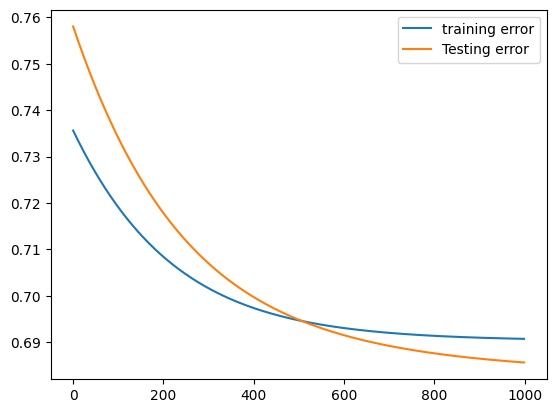

In [163]:
from matplotlib import pyplot as plt
plt.plot(train_loss, label = "training error")
plt.plot(test_loss, label = "Testing error")
plt.legend()
plt.show()

In [164]:
def train_model(epochs, lr, weight_decay):
    model = LogisticRegressionModel(X.shape[1])
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    epochs = epochs
    train_loss = []
    test_loss = []
    test_accuracy = []
    for epoch in range(epochs):
        model.train()
        yhat = model(X_train).view(-1)
        loss = criterion(yhat, y_train)
        predictions = (yhat > 0.5).float()
        train_correct = (predictions == y_train).sum().item()
        train_loss.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        yhat = model(X_test).view(-1)
        loss = criterion(yhat, y_test)
        predictions = (yhat > 0.5).float()
        test_correct = (predictions == y_test).sum().item()
        test_loss.append(loss.item())

    p_train = (train_correct / X_train.shape[0]) * 100
    p_test = (test_correct / X_test.shape[0]) * 100
    test_accuracy.append(p_test)

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Loss = {train_loss[epoch]:.4f}, Accuracy = {p_train:.2f}%")
        print(f"Epoch {epoch}: Test Loss = {test_loss[epoch]:.4f}, Accuracy = {p_test:.2f}%")
    
    best_accuracy = max(test_accuracy)
    
    return best_accuracy

accuracy = train_model(epochs=1000, lr=0.01, weight_decay=0.01)

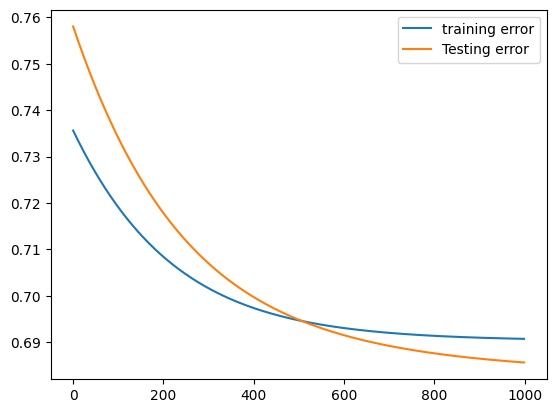

In [165]:
from matplotlib import pyplot as plt
plt.plot(train_loss, label = "training error")
plt.plot(test_loss, label = "Testing error")
plt.legend()
plt.show()

In [166]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report, auc
import itertools
import numpy as np
y = np.concatenate([y_train.numpy(), y_test.numpy()])
y_pred = np.concatenate([predictions_train_result, predictions_test_result])
cm = confusion_matrix(y, y_pred)
print(cm)


[[204 286]
 [186 324]]


210


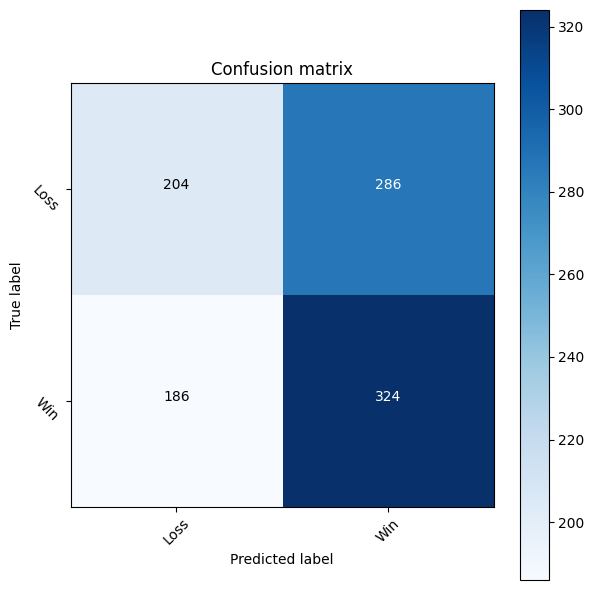

In [167]:
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()

tick_marks = range(2)
plt.xticks(tick_marks, ['Loss', 'Win'], rotation=45)
plt.yticks(tick_marks, ['Loss', 'Win'], rotation=-45)

thresh = 210
print(thresh)
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
    

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()




In [168]:
print(classification_report(y, y_pred, target_names=['Losses', 'Win']))

              precision    recall  f1-score   support

      Losses       0.52      0.42      0.46       490
         Win       0.53      0.64      0.58       510

    accuracy                           0.53      1000
   macro avg       0.53      0.53      0.52      1000
weighted avg       0.53      0.53      0.52      1000



0.5258103241296518


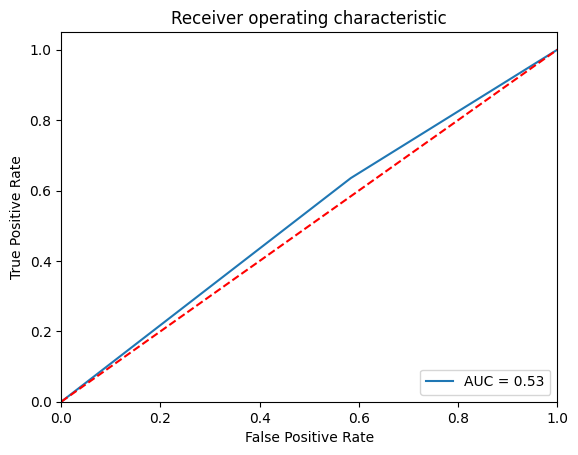

In [169]:
fpr, tpr, thresholds = roc_curve(y, y_pred)
auc = roc_auc_score(y, y_pred)
print(auc)
plt.plot(fpr, tpr, label='AUC = %0.2f' % auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()



In [170]:
torch.save(model.state_dict(), 'league_of_legends_model.pth')

In [171]:
model = LogisticRegressionModel(X_test.shape[1])
model.load_state_dict(torch.load('league_of_legends_model.pth'))
model.eval()
with torch.no_grad():
    yhat = model(X_test).view(-1)
    predictions = (yhat > 0.5).float()
    test_correct = (predictions == y_test).sum().item()

    p_test = (test_correct / X_test.shape[0]) * 100
    
    print(p_test)



54.50000000000001


In [172]:
lrs = [0.01, 0.05, 0.1]
epochs = [100, 1000, 5000]
accuracies = []
for lr, epoch in itertools.product(lrs, epochs):
    acc = train_model(epochs=epoch, lr=lr, weight_decay=0.01)
    accuracies.append({"lr": lr, "epoch": epoch, "acc": acc})
    



In [173]:
best_config = max(accuracies, key=lambda x: x['acc'])
print(f"Best: lr={best_config['lr']}, epoch={best_config['epoch']}, acc={best_config['acc']:.2f}")



Best: lr=0.1, epoch=100, acc=55.50


In [174]:
model.linear.weight.data.numpy()

array([[ 0.04773761,  0.00627184, -0.02036504,  0.03313993, -0.02483478,
         0.08860838,  0.00104536, -0.04409067]], dtype=float32)

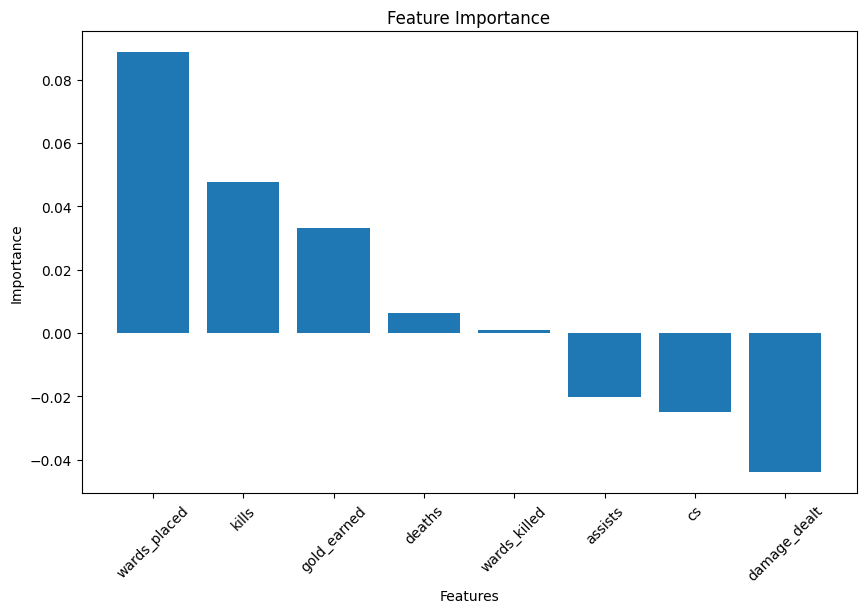

In [175]:
weights = model.linear.weight.data.numpy().flatten()
feature_importance = pd.DataFrame({'Feature': column_name, 'Importance': weights})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()
